In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_path = "/kaggle/input/competitions/shopee-product-matching/train.csv"

train = pd.read_csv(train_path)

print("Shape:", train.shape)
print(train.head())

Shape: (34250, 5)
         posting_id                                 image       image_phash  \
0   train_129225211  0000a68812bc7e98c42888dfb1c07da0.jpg  94974f937d4c2433   
1  train_3386243561  00039780dfc94d01db8676fe789ecd05.jpg  af3f9460c2838f0f   
2  train_2288590299  000a190fdd715a2a36faed16e2c65df7.jpg  b94cb00ed3e50f78   
3  train_2406599165  00117e4fc239b1b641ff08340b429633.jpg  8514fc58eafea283   
4  train_3369186413  00136d1cf4edede0203f32f05f660588.jpg  a6f319f924ad708c   

                                               title  label_group  
0                          Paper Bag Victoria Secret    249114794  
1  Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...   2937985045  
2        Maling TTS Canned Pork Luncheon Meat 397 gr   2395904891  
3  Daster Batik Lengan pendek - Motif Acak / Camp...   4093212188  
4                  Nescafe \xc3\x89clair Latte 220ml   3648931069  


In [3]:
positive_pairs = []

for group_id, group in train.groupby("label_group"):

    indices = list(group.index)

    for i in range(len(indices)):
        for j in range(i + 1, len(indices)):

            positive_pairs.append(
                (indices[i], indices[j], 1)
            )

print("Positive pairs:", len(positive_pairs))

Positive pairs: 83751


In [4]:
import random

random.seed(42)

negative_pairs = []

all_indices = list(train.index)

while len(negative_pairs) < len(positive_pairs):

    i, j = random.sample(all_indices, 2)

    if train.loc[i, "label_group"] != train.loc[j, "label_group"]:

        negative_pairs.append(
            (i, j, 0)
        )

print("Negative pairs:", len(negative_pairs))

Negative pairs: 83751


In [5]:
pairs = positive_pairs + negative_pairs

random.shuffle(pairs)

pairs_df = pd.DataFrame(
    pairs,
    columns=["idx1", "idx2", "label"]
)

print("Total pairs:", len(pairs_df))
print("\nClass distribution:")
print(pairs_df["label"].value_counts())

Total pairs: 167502

Class distribution:
label
0    83751
1    83751
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

pairs_train, pairs_test = train_test_split(
    pairs_df,
    test_size=0.2,
    random_state=42,
    stratify=pairs_df["label"]
)

print("Training pairs:", len(pairs_train))
print("Testing pairs:", len(pairs_test))

Training pairs: 134001
Testing pairs: 33501


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_word = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2
)

title_vectors = vectorizer_word.fit_transform(
    train["title"]
)

print("TF-IDF matrix shape:", title_vectors.shape)

TF-IDF matrix shape: (34250, 58130)


In [8]:
from sklearn.metrics.pairwise import cosine_similarity

idx1 = pairs_test["idx1"].values
idx2 = pairs_test["idx2"].values

similarities = cosine_similarity(
    title_vectors[idx1],
    title_vectors[idx2]
).diagonal()

pairs_test = pairs_test.copy()

pairs_test["similarity"] = similarities

print(pairs_test.head(10))

         idx1   idx2  label  similarity
78086    8305  30497      1    0.536214
13317    7705   7707      1    0.437658
95897   27046  30681      0    0.000000
79693   14414  19240      1    0.920175
151713  19922   6091      0    0.000000
123219     82  34060      1    0.075259
72236   10475  18301      1    0.239716
127374  19855  31733      1    0.676221
55136    1915  34049      0    0.000000
86022   33374   9812      0    0.000000


In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

threshold = 0.5

predictions = (
    pairs_test["similarity"] >= threshold
).astype(int)

y_true = pairs_test["label"]

print("Accuracy :", accuracy_score(y_true, predictions))
print("Precision:", precision_score(y_true, predictions))
print("Recall   :", recall_score(y_true, predictions))
print("F1 Score :", f1_score(y_true, predictions))

Accuracy : 0.6852034267633802
Precision: 0.999838865613922
Recall   : 0.37044776119402983
F1 Score : 0.5405994075622931


In [10]:
threshold_results = []

for threshold in np.arange(0.1, 1.0, 0.05):

    predictions = (
        pairs_test["similarity"] >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(y_true, predictions),
        "recall": recall_score(y_true, predictions),
        "f1": f1_score(y_true, predictions)
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

    threshold  precision    recall        f1
0        0.10   0.997339  0.917552  0.955784
1        0.15   0.998682  0.859403  0.923822
2        0.20   0.999098  0.793970  0.884801
3        0.25   0.999424  0.725194  0.840507
4        0.30   0.999725  0.651343  0.788779
5        0.35   0.999793  0.576597  0.731390
6        0.40   0.999882  0.504119  0.670292
7        0.45   0.999862  0.433612  0.604897
8        0.50   0.999839  0.370448  0.540599
9        0.55   0.999810  0.313731  0.477597
10       0.60   0.999773  0.262627  0.415981
11       0.65   0.999726  0.217493  0.357262
12       0.70   0.999663  0.177075  0.300857
13       0.75   0.999589  0.145373  0.253831
14       0.80   1.000000  0.115045  0.206350
15       0.85   1.000000  0.087582  0.161058
16       0.90   1.000000  0.066388  0.124510
17       0.95   1.000000  0.045373  0.086808


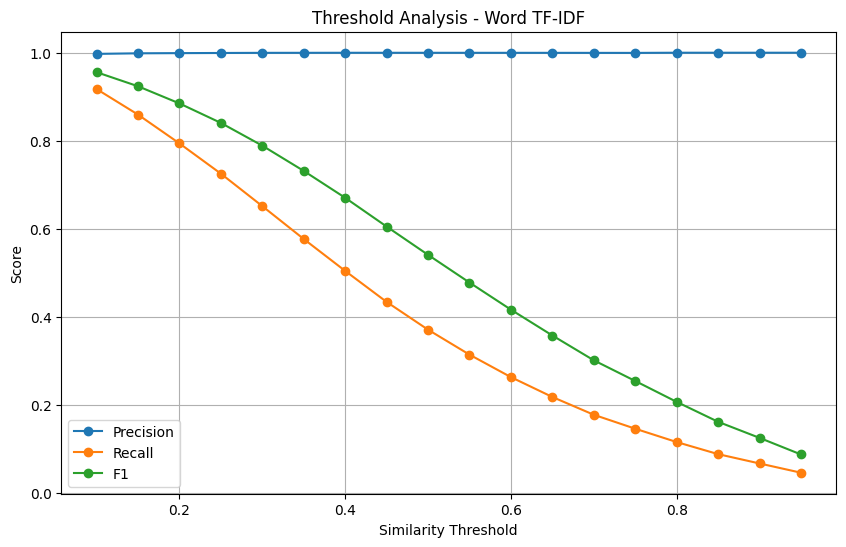

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Similarity Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis - Word TF-IDF")
plt.legend()
plt.grid()
plt.show()

In [14]:
#character TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_word = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=3,
    max_features=50000
)

title_vectors = vectorizer_word.fit_transform(train["title"])

print("TF-IDF matrix shape:", title_vectors.shape)

TF-IDF matrix shape: (34250, 30660)


In [15]:
similarities = cosine_similarity(
    title_vectors[idx1],
    title_vectors[idx2]
).diagonal()

pairs_test = pairs_test.copy()
pairs_test["similarity"] = similarities

print(pairs_test.head(10))

         idx1   idx2  label  similarity
78086    8305  30497      1    0.536214
13317    7705   7707      1    0.493573
95897   27046  30681      0    0.000000
79693   14414  19240      1    0.948904
151713  19922   6091      0    0.000000
123219     82  34060      1    0.105798
72236   10475  18301      1    0.239716
127374  19855  31733      1    0.676221
55136    1915  34049      0    0.000000
86022   33374   9812      0    0.000000


In [16]:
threshold = 0.5

predictions = (
    pairs_test["similarity"] >= threshold
).astype(int)

y_true = pairs_test["label"]

print("Accuracy :", accuracy_score(y_true, predictions))
print("Precision:", precision_score(y_true, predictions))
print("Recall   :", recall_score(y_true, predictions))
print("F1 Score :", f1_score(y_true, predictions))

Accuracy : 0.709829557326647
Precision: 0.9998577727208079
Recall   : 0.4197014925373134
F1 Score : 0.5912282914932089


In [17]:
#threshold analysis
threshold_results = []

for threshold in np.arange(0.1, 1.0, 0.05):

    predictions = (
        pairs_test["similarity"] >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(y_true, predictions),
        "recall": recall_score(y_true, predictions),
        "f1": f1_score(y_true, predictions)
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

    threshold  precision    recall        f1
0        0.10   0.995853  0.931940  0.962837
1        0.15   0.998107  0.881552  0.936216
2        0.20   0.998697  0.823821  0.902869
3        0.25   0.999143  0.765672  0.866964
4        0.30   0.999574  0.699642  0.823137
5        0.35   0.999620  0.627881  0.771296
6        0.40   0.999786  0.556657  0.715140
7        0.45   0.999878  0.488418  0.656265
8        0.50   0.999858  0.419701  0.591228
9        0.55   0.999835  0.361313  0.530807
10       0.60   0.999804  0.304537  0.466868
11       0.65   0.999765  0.254209  0.405350
12       0.70   0.999711  0.206328  0.342060
13       0.75   0.999643  0.167284  0.286606
14       0.80   0.999554  0.133791  0.235994
15       0.85   1.000000  0.100657  0.182903
16       0.90   1.000000  0.074567  0.138785
17       0.95   1.000000  0.050388  0.095942


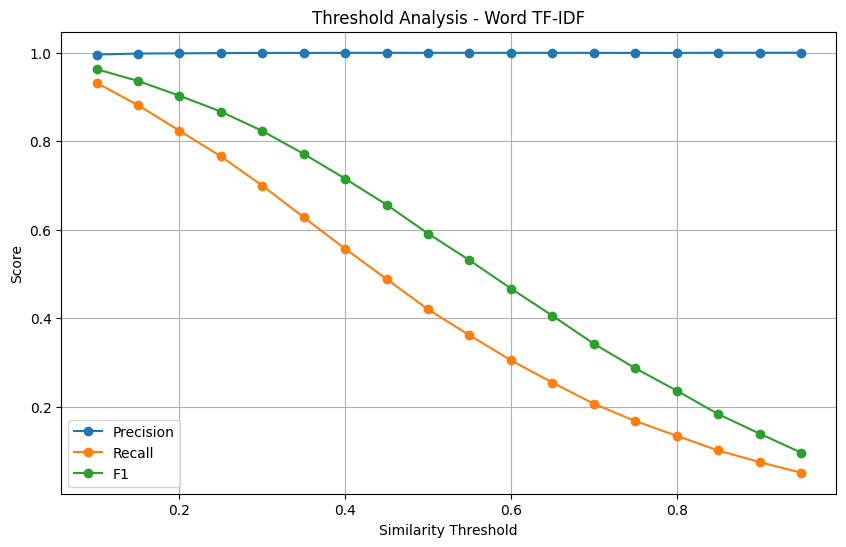

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Similarity Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis - Word TF-IDF")
plt.legend()
plt.grid()
plt.show()

In [19]:
best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("Best threshold:")
print(best_row)

Best threshold:
threshold    0.100000
precision    0.995853
recall       0.931940
f1           0.962837
Name: 0, dtype: float64


In [21]:
vectorizer_char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=3,
    max_features=50000
)

title_vectors_char = vectorizer_char.fit_transform(train["title"])

print("Character TF-IDF matrix shape:", title_vectors_char.shape)

Character TF-IDF matrix shape: (34250, 50000)


In [22]:
similarities_char = cosine_similarity(
    title_vectors_char[idx1],
    title_vectors_char[idx2]
).diagonal()

pairs_test["similarity_char"] = similarities_char

print(pairs_test[["label", "similarity_char"]].head())

        label  similarity_char
78086       1         0.416935
13317       1         0.488460
95897       0         0.005848
79693       1         0.971936
151713      0         0.000000


In [24]:
threshold = 0.5

predictions_char = (
    pairs_test["similarity_char"] >= threshold
).astype(int)

y_true = pairs_test["label"]

print("Character TF-IDF")
print("Accuracy :", accuracy_score(y_true, predictions_char))
print("Precision:", precision_score(y_true, predictions_char))
print("Recall   :", recall_score(y_true, predictions_char))
print("F1 Score :", f1_score(y_true, predictions_char))

Character TF-IDF
Accuracy : 0.7438882421420256
Precision: 0.9997553217518963
Recall   : 0.48788059701492537
F1 Score : 0.6557534906114588


In [25]:
threshold_results_char = []

for threshold in np.arange(0.1, 1.0, 0.05):
    predictions = (
        pairs_test["similarity_char"] >= threshold
    ).astype(int)

    threshold_results_char.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(y_true, predictions),
        "recall": recall_score(y_true, predictions),
        "f1": f1_score(y_true, predictions)
    })

threshold_df_char = pd.DataFrame(threshold_results_char)

print(threshold_df_char)

    threshold  precision    recall        f1
0        0.10   0.990895  0.961552  0.976003
1        0.15   0.996444  0.936896  0.965753
2        0.20   0.998608  0.899224  0.946314
3        0.25   0.999231  0.853194  0.920456
4        0.30   0.999476  0.796418  0.886467
5        0.35   0.999591  0.729134  0.843206
6        0.40   0.999725  0.651403  0.788823
7        0.45   0.999791  0.570149  0.726181
8        0.50   0.999755  0.487881  0.655753
9        0.55   0.999854  0.409612  0.581145
10       0.60   0.999821  0.333075  0.499687
11       0.65   1.000000  0.267522  0.422119
12       0.70   1.000000  0.210866  0.348289
13       0.75   1.000000  0.164537  0.282580
14       0.80   1.000000  0.126985  0.225354
15       0.85   1.000000  0.091045  0.166895
16       0.90   1.000000  0.061970  0.116708
17       0.95   1.000000  0.039463  0.075929


In [26]:
best_row_char = threshold_df_char.loc[
    threshold_df_char["f1"].idxmax()
]

print("Best character TF-IDF threshold:")
print(best_row_char)

Best character TF-IDF threshold:
threshold    0.100000
precision    0.990895
recall       0.961552
f1           0.976003
Name: 0, dtype: float64


In [27]:
#create predictions
best_threshold = 0.10

pairs_test_analysis = pairs_test.copy()

pairs_test_analysis["prediction"] = (
    pairs_test_analysis["similarity_char"] >= best_threshold
).astype(int)

pairs_test_analysis["error_type"] = "Correct"

pairs_test_analysis.loc[
    (pairs_test_analysis["label"] == 1) &
    (pairs_test_analysis["prediction"] == 0),
    "error_type"
] = "False Negative"

pairs_test_analysis.loc[
    (pairs_test_analysis["label"] == 0) &
    (pairs_test_analysis["prediction"] == 1),
    "error_type"
] = "False Positive"

print(pairs_test_analysis["error_type"].value_counts())

error_type
Correct           32709
False Negative      644
False Positive      148
Name: count, dtype: int64


In [28]:
# False positives
fp = pairs_test_analysis[
    pairs_test_analysis["error_type"] == "False Positive"
].head(10)

print("FALSE POSITIVES")
for _, row in fp.iterrows():
    print("\nTitle 1:", train.loc[row["idx1"], "title"])
    print("Title 2:", train.loc[row["idx2"], "title"])
    print("Similarity:", row["similarity_char"])
    print("Actual label:", row["label"])

FALSE POSITIVES

Title 1: Wardah Acnederm Pure Foaming Cleanser 60 ml
Title 2: NEOGEN Real Flower Cleansing Water
Similarity: 0.10903690061724325
Actual label: 0

Title 1: Edufuntoys - 3D PUZZLE ANIMAL - Puzzle 3D hewan/ mearangkai puzzle 3 dimensi
Title 2: Puzzle kayu / wooden puzzle / mainan edukasi / knob puzzle
Similarity: 0.5150199559406528
Actual label: 0

Title 1: All Perfect Acne Beauty Set (Essence Toner 100ml + Fresh Calming Serum
Title 2: Y.O.U Dream Skin Perfect Cushion | YOU
Similarity: 0.14050797875434115
Actual label: 0

Title 1: FLIP FLOP Sendal Spon Mutiara
Title 2: Handuk Mutia Jumbo Ukuran 70x140 Termurah
Similarity: 0.10302079943824818
Actual label: 0

Title 1: Termometer Suhu Ruangan / Thermometer Digital Mini Kolam Tubuh Kulkas
Title 2: Drawer Safety Pengaman Lemari / Kulkas
Similarity: 0.10402519101850055
Actual label: 0

Title 1: Tas Wanita Import Jinjing Selempang CHIBAO Mini CB5891 5891 Parasut Kualitas Super Quality Impor
Title 2: Tas wanita chale dan keth 2 

In [29]:
# False negatives
fn = pairs_test_analysis[
    pairs_test_analysis["error_type"] == "False Negative"
].head(10)

print("\nFALSE NEGATIVES")
for _, row in fn.iterrows():
    print("\nTitle 1:", train.loc[row["idx1"], "title"])
    print("Title 2:", train.loc[row["idx2"], "title"])
    print("Similarity:", row["similarity_char"])
    print("Actual label:", row["label"])


FALSE NEGATIVES

Title 1: \xe2\x9d\xa4\xef\xb8\x8fGROSIR\xe2\x9d\xa4\xef\xb8\x8f Viva Milk Cleanser / Face Tonic 100ml
Title 2: ORIGINAL Viva Penyegar Air Mawar Toner 100 ML
Similarity: 0.06006832650338688
Actual label: 1

Title 1: EDW H68 Gantungan Hook Kail Barang Baju Serbaguna Hanger Tempel Dinding Kuat
Title 2: 1pc Kait Model Transparan Dengan Perekat Kuat
Similarity: 0.08668023881958815
Actual label: 1

Title 1: Apd face shield up and down
Title 2: sandal japit santai anti kesemutan bahan karet
Similarity: 0.007609105666752352
Actual label: 1

Title 1: DRESS MUSLIM TERBARU / GAMIS RAHNEM GM - 22 / FASHION MUSLIM 20% OFF
Title 2: Amore Signature Dress
Similarity: 0.04613548668587935
Actual label: 1

Title 1: \xe3\x80\x90One order just buy 1pcs Rp999,Other excess products will not be shipped\xe3\x80\x91Random Color Ready S4 S6 Headphones I9300 Mobile Phone Headphones Wired Earphones Universal
Title 2: BJBACC | HEADSET / HANDSFREE U19 MACAROON MATE COLOR HIFI EXTRA BASS SUARA MANTA

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    pairs_test_analysis["label"],
    pairs_test_analysis["prediction"]
)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Confusion Matrix:
[[16603   148]
 [  644 16106]]

True Negatives : 16603
False Positives: 148
False Negatives: 644
True Positives : 16106
